In this notebook, the ArBr structures are featurized for the ScopeBO modeling.

NOTE: This notebook was run with the autoqchem python environment.

In [1]:
from autoqchem.db_functions import descriptors
from collections import Counter
from rdkit.Chem import Draw
from rdkit import Chem
import pandas as pd
import numpy as np
import logging
logging.basicConfig(level=logging.INFO)

### Read in the yield data

In [2]:
# read in the NMR yields from the modeling part of the study
yields = pd.read_csv("arbr_pred_yields.csv",index_col=0,header=0)
yields.head()

,yield
O=Cc1cccc(Br)c1,36.663021
Brc1cccc2ccccc12,0.573380
COc1ccccc1Br,36.329123
C=Cc1ccc(Br)cc1,68.163867
COc1cccc(Br)c1,61.922149


In [3]:
# dowload descriptors
data = descriptors(tags=["ArBr_scope_SJ"],presets=["global","substructure"],conf_option="boltzmann",solvent="None",
                functional="APFD",basis_set="6-31G*",substructure="cBr")

# Process the data so that it is in one dataframe
label_dict={}
for key in data:
    if key != "global":
        # atom descriptor dataframes are by default called atom1, atom2, etc. --> replace with the atom type and a running number (e. g. "C1" and "C2")
        if data[key].iloc[0,-1] not in label_dict:
            label_dict[data[key].iloc[0,-1]] = 1
        else:
            label_dict[data[key].iloc[0,-1]] += 1
        label = data[key].iloc[0,-1]+str(label_dict[data[key].iloc[0,-1]])
        data[key].drop(columns=["labels","X","Y","Z"],inplace=True)
        data[key].columns = [f"{label}_{column}" for column in data[key].columns]
    else:
        data[key].drop(columns=["converged","multiplicity"],inplace=True)

df_combined = pd.concat(data,axis=1)
df_combined.columns = [multi_column_index[1] for multi_column_index in df_combined.columns]
print(f"Downloaded descriptors for {len(df_combined)} compounds.")
df_combined.head()

Downloaded descriptors for 2683 compounds.


,E,ES_root_dipole,ES_root_electronic_spatial_extent,ES_root_molar_volume,E_scf,E_thermal_correction,E_zpe,G,G_thermal_correction,H,...,Br1_ES_root_NPA_valence,Br1_Mulliken_charge,Br1_NMR_anisotropy,Br1_NMR_shift,Br1_NPA_Rydberg,Br1_NPA_charge,Br1_NPA_core,Br1_NPA_total,Br1_NPA_valence,Br1_VBur
can,,,,,,,,,,,,,,,,,,,,,
Br/C=C/c1ccc(cc1)Br,-5451.075603,0.321852,5928.807428,1438.482766,-5451.194697,0.124226,-5451.085140,-5451.123648,0.076182,-5451.074659,...,6.831555,-0.101,1059.312641,2225.480054,0.01805,0.07366,27.9991,34.92634,6.909195,0.375079
Br/C=C\c1ccc(cc1)Br,-5451.076012,1.005900,4774.224400,1167.995000,-5451.193774,0.124537,-5451.085223,-5451.123666,0.076883,-5451.075068,...,6.82223,-0.102042,1060.6876,2221.3535,0.01801,0.07284,27.9991,34.92716,6.91005,0.376337
Br[13c]1[13cH][13cH][13cH][13cH][13cH]1,-2802.861780,0.165900,1225.196300,1085.477000,-2802.957409,0.095831,-2802.867555,-2802.898597,0.059015,-2802.860836,...,6.78637,-0.111596,1096.7618,2225.4495,0.01784,0.06213,27.99911,34.93787,6.92092,0.375393
Brc1c(C)cc(cc1C)C(C)(C)C,-3038.391971,0.952600,4103.383000,1678.335000,-3038.663774,0.275705,-3038.406242,-3038.447065,0.220611,-3038.391027,...,6.87022,-0.121283,647.083,2334.5876,0.01649,0.04655,27.99909,34.95345,6.93788,0.43927
Brc1c(C)ccc2c1ccc(c2Br)C,-5605.768539,0.000500,5519.826100,1838.182000,-5605.959621,0.197892,-5605.781425,-5605.822171,0.144260,-5605.767595,...,6.87778,-0.10108,701.8452,2335.5578,0.01658,0.06099,27.99908,34.93901,6.92335,0.437618


In [4]:
# check for any duplicate smiles in the dataset (with just a change in absolute stereochemistry)
smiles_comp = {x: Chem.MolToSmiles(Chem.MolFromSmiles(x),isomericSmiles=False) for x in df_combined.index}

len(set(list(smiles_comp.values())))

2664

Autoqchem does not capture absolute stereochemistry and the featurization for the example sets above (apart from the first one with alkene isomers) is therefore not differentiated. Furthermore, the aryl bromide methylation is not chiral and the reaction outcome is therefore also not dependent on the absolute stereochemistry. Therefore, we removed these redundant compounds from the dataset.

Compound sets only differing in the absolute stereochemistry in the dataset:


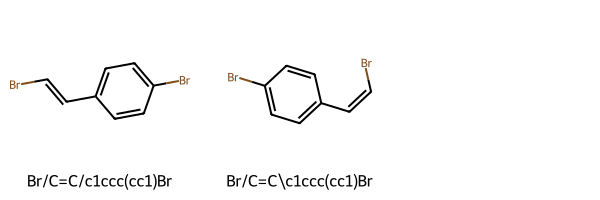

['Br/C=C/c1ccc(cc1)Br', 'Br/C=C\\c1ccc(cc1)Br'] 




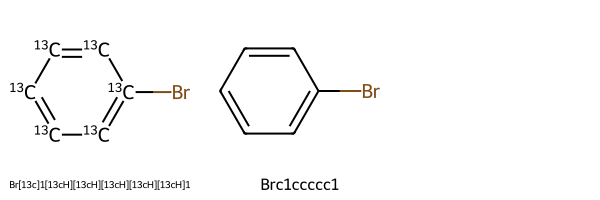

['Br[13c]1[13cH][13cH][13cH][13cH][13cH]1', 'Brc1ccccc1'] 




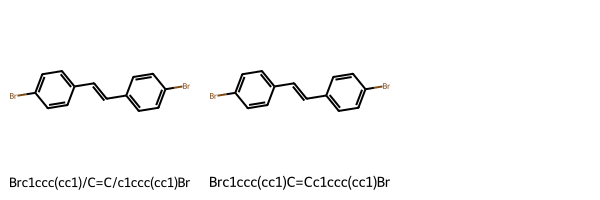

['Brc1ccc(cc1)/C=C/c1ccc(cc1)Br', 'Brc1ccc(cc1)C=Cc1ccc(cc1)Br'] 




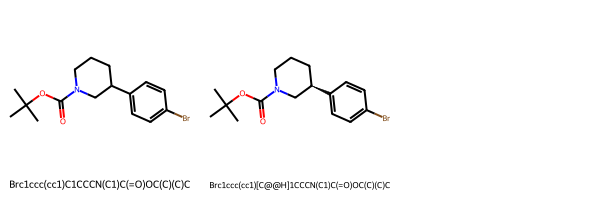

['Brc1ccc(cc1)C1CCCN(C1)C(=O)OC(C)(C)C', 'Brc1ccc(cc1)[C@@H]1CCCN(C1)C(=O)OC(C)(C)C'] 




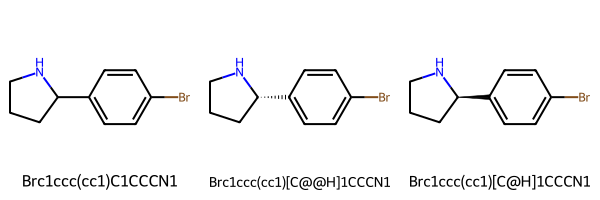

['Brc1ccc(cc1)C1CCCN1', 'Brc1ccc(cc1)[C@@H]1CCCN1', 'Brc1ccc(cc1)[C@H]1CCCN1'] 




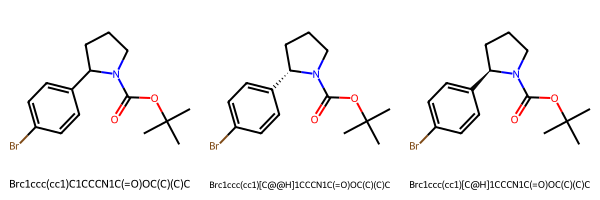

['Brc1ccc(cc1)C1CCCN1C(=O)OC(C)(C)C', 'Brc1ccc(cc1)[C@@H]1CCCN1C(=O)OC(C)(C)C', 'Brc1ccc(cc1)[C@H]1CCCN1C(=O)OC(C)(C)C'] 




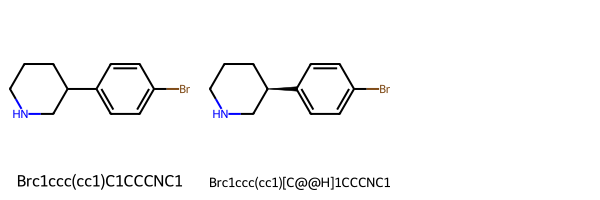

['Brc1ccc(cc1)C1CCCNC1', 'Brc1ccc(cc1)[C@@H]1CCCNC1'] 




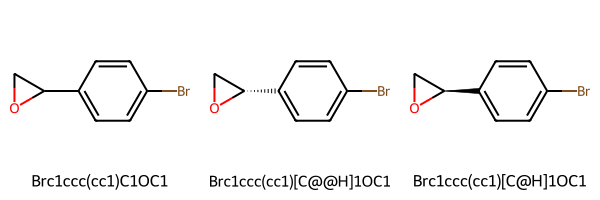

['Brc1ccc(cc1)C1OC1', 'Brc1ccc(cc1)[C@@H]1OC1', 'Brc1ccc(cc1)[C@H]1OC1'] 




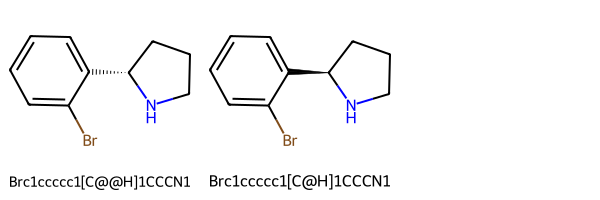

['Brc1ccccc1[C@@H]1CCCN1', 'Brc1ccccc1[C@H]1CCCN1'] 




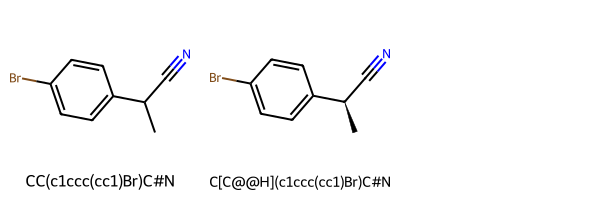

['CC(c1ccc(cc1)Br)C#N', 'C[C@@H](c1ccc(cc1)Br)C#N'] 




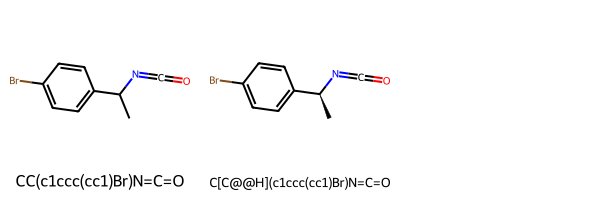

['CC(c1ccc(cc1)Br)N=C=O', 'C[C@@H](c1ccc(cc1)Br)N=C=O'] 




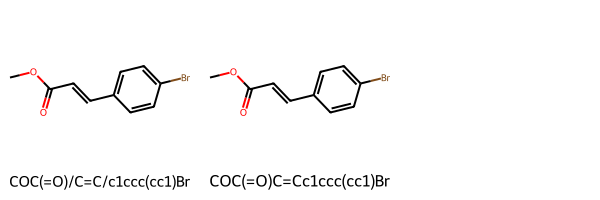

['COC(=O)/C=C/c1ccc(cc1)Br', 'COC(=O)C=Cc1ccc(cc1)Br'] 




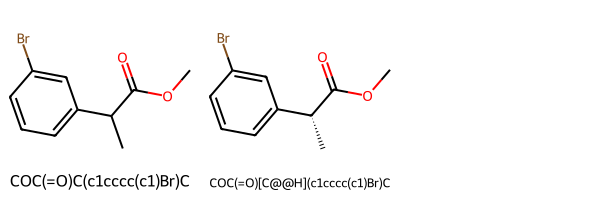

['COC(=O)C(c1cccc(c1)Br)C', 'COC(=O)[C@@H](c1cccc(c1)Br)C'] 




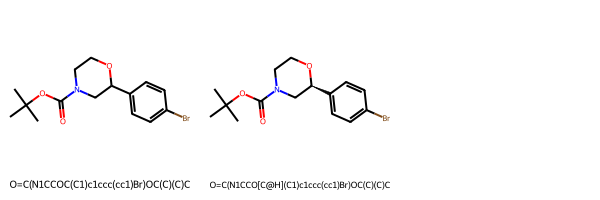

['O=C(N1CCOC(C1)c1ccc(cc1)Br)OC(C)(C)C', 'O=C(N1CCO[C@H](C1)c1ccc(cc1)Br)OC(C)(C)C'] 




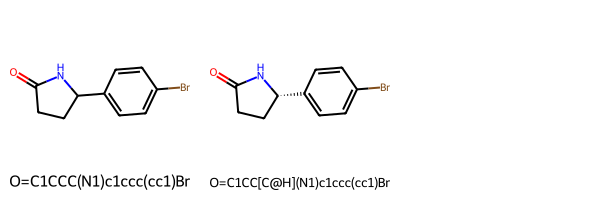

['O=C1CCC(N1)c1ccc(cc1)Br', 'O=C1CC[C@H](N1)c1ccc(cc1)Br'] 




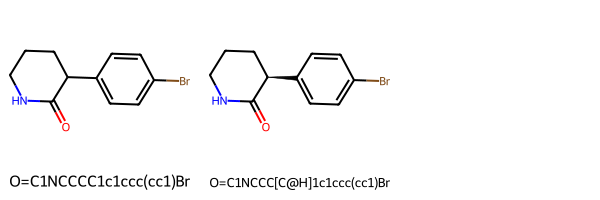

['O=C1NCCCC1c1ccc(cc1)Br', 'O=C1NCCC[C@H]1c1ccc(cc1)Br'] 




In [5]:
counts = Counter(smiles_comp.values())
dup_counts = {v: count_ for v,count_ in counts.items() if counts[v] > 1}
dup_keys = {k:v for k, v in smiles_comp.items() if counts[v] > 1}
print("Compound sets only differing in the absolute stereochemistry in the dataset:")
for smiles in dup_counts.keys():
    display(Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in [y for y,z in dup_keys.items() if z == smiles]],
            legends = [y for y,z in dup_keys.items() if z == smiles]))
    print([y for y,z in dup_keys.items() if z == smiles],"\n\n")
    

The following smiles are removed from the dataset because of redundancy:
['Br[13c]1[13cH][13cH][13cH][13cH][13cH]1', 'Brc1ccc(cc1)C=Cc1ccc(cc1)Br', 'Brc1ccc(cc1)[C@@H]1CCCN(C1)C(=O)OC(C)(C)C', 'Brc1ccc(cc1)[C@@H]1CCCN1', 'Brc1ccc(cc1)[C@H]1CCCN1', 'Brc1ccc(cc1)[C@@H]1CCCN1C(=O)OC(C)(C)C', 'Brc1ccc(cc1)[C@H]1CCCN1C(=O)OC(C)(C)C', 'Brc1ccc(cc1)[C@@H]1CCCNC1', 'Brc1ccc(cc1)[C@@H]1OC1', 'Brc1ccc(cc1)[C@H]1OC1', 'Brc1ccccc1[C@H]1CCCN1', 'C[C@@H](c1ccc(cc1)Br)C#N', 'C[C@@H](c1ccc(cc1)Br)N=C=O', 'COC(=O)C=Cc1ccc(cc1)Br', 'COC(=O)[C@@H](c1cccc(c1)Br)C', 'O=C(N1CCO[C@H](C1)c1ccc(cc1)Br)OC(C)(C)C', 'O=C1CC[C@H](N1)c1ccc(cc1)Br', 'O=C1NCCC[C@H]1c1ccc(cc1)Br']


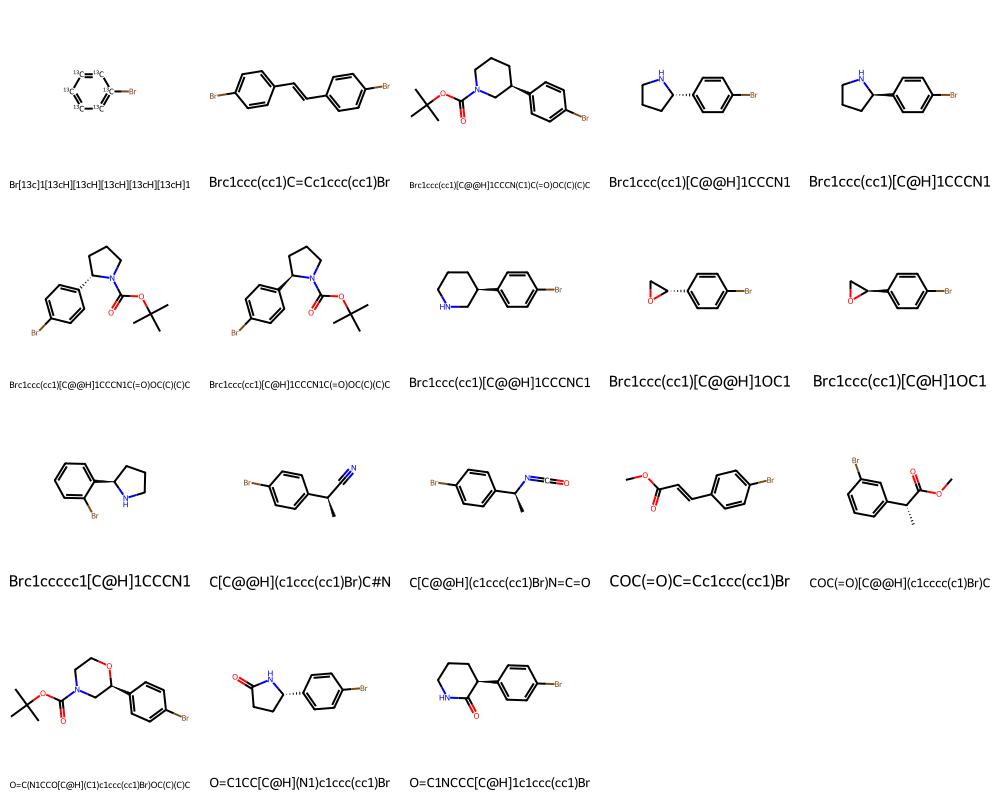

In [6]:
smiles_to_drop = []
for i,smiles in enumerate(dup_counts.keys()):
    dup_smiles = [y for y,z in dup_keys.items() if z == smiles]
    if i != 0:  # skip the first set as there are actually different isomers
        if i == 1:
            smiles_to_drop.append(dup_smiles[0])  # remove the 13C-PhBr and keep PhBr for simplicity
        else:
            smiles_to_drop += [smiles for smiles in dup_smiles if smiles != dup_smiles[0]]
print("The following smiles are removed from the dataset because of redundancy:")
print(smiles_to_drop)
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in smiles_to_drop],legends = smiles_to_drop, molsPerRow=5)

In [7]:
df_combined = df_combined.drop(smiles_to_drop)
print("Size of the dataset after dropping redundant compounds:",len(df_combined))

Size of the dataset after dropping redundant compounds: 2665


In [8]:
def feature_preprocessing(df):
    """
    Function for removing non-varied and highly correlated features.
    Take a df as input and returns it in processed form.
    """
    # Remove columns that have only one unique value.
    removed_columns = []
    for column in df.columns:
        if len(np.unique(df[column].values)) < 2:
            removed_columns.append(column)
    df = df.drop(removed_columns, axis=1)
    
    # Remove highly correlated features
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    df = df.drop(to_drop, axis=1)

    # Store the names of the column removed due to correlation
    for column in to_drop:
        removed_columns.append(column)

    print(f"The following features were removed: {removed_columns}")
    
    return df

df = feature_preprocessing(df_combined)
print("Number of features in the final dataset:", len(df.columns))

The following features were removed: ['charge', 'E_scf', 'E_zpe', 'G', 'G_thermal_correction', 'H', 'H_thermal_correction', 'electronic_spatial_extent', 'number_of_atoms', 'zero_point_correction', 'C1_ES_root_NPA_total', 'C1_ES_root_NPA_valence', 'C1_NPA_core', 'C1_NPA_total', 'C1_NPA_valence', 'Br1_ES_root_NPA_charge', 'Br1_ES_root_NPA_total', 'Br1_ES_root_NPA_valence', 'Br1_NPA_charge', 'Br1_NPA_total', 'Br1_NPA_valence', 'Br1_VBur']
Number of features in the final dataset: 32


In [9]:
df

,E,ES_root_dipole,ES_root_electronic_spatial_extent,ES_root_molar_volume,E_thermal_correction,dipole,electronegativity,hardness,homo_energy,lumo_energy,...,C1_VBur,Br1_APT_charge,Br1_ES_root_Mulliken_charge,Br1_ES_root_NPA_Rydberg,Br1_ES_root_NPA_core,Br1_Mulliken_charge,Br1_NMR_anisotropy,Br1_NMR_shift,Br1_NPA_Rydberg,Br1_NPA_core
can,,,,,,,,,,,,,,,,,,,,,
Br/C=C/c1ccc(cc1)Br,-5451.075603,0.321852,5928.807428,1438.482766,0.124226,0.221741,0.142693,0.090492,-0.233185,-0.052200,...,0.609661,-0.301977,-0.041863,0.02002,27.99901,-0.101,1059.312641,2225.480054,0.01805,27.9991
Br/C=C\c1ccc(cc1)Br,-5451.076012,1.005900,4774.224400,1167.995000,0.124537,2.112400,0.142680,0.091700,-0.234380,-0.050980,...,0.611863,-0.30097,-0.034957,0.02033,27.99899,-0.102042,1060.6876,2221.3535,0.01801,27.9991
Brc1c(C)cc(cc1C)C(C)(C)C,-3038.391971,0.952600,4103.383000,1678.335000,0.275705,1.759900,0.118575,0.115175,-0.233750,-0.003400,...,0.683134,-0.273502,-0.066805,0.01772,27.99902,-0.121283,647.083,2334.5876,0.01649,27.99909
Brc1c(C)ccc2c1ccc(c2Br)C,-5605.768539,0.000500,5519.826100,1838.182000,0.197892,0.024400,0.137590,0.085440,-0.223030,-0.052150,...,0.67983,-0.250813,-0.06508,0.01794,27.99903,-0.10108,701.8452,2335.5578,0.01658,27.99908
Brc1c(C)cccc1Cl,-3301.607584,1.517700,1905.908300,1133.561000,0.118215,2.685000,0.135985,0.115975,-0.251960,-0.020010,...,0.678099,-0.190686,-0.020651,0.01913,27.99898,-0.07464,762.4611,2252.7752,0.0176,27.99905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[C-]#[N+]C(S(=O)(=O)c1ccc(cc1)C)c1cccc(c1)Br,-3752.629316,8.970254,6070.011822,2127.062059,0.256348,4.651156,0.158386,0.106708,-0.265094,-0.051678,...,0.675689,-0.221117,0.08784,0.017613,27.998875,-0.098702,1084.896312,2215.42393,0.01809,27.999026
[C-]#[N+]Cc1cccc(c1)Br,-2934.239252,3.669300,2691.361000,1135.291000,0.127170,3.715000,0.142930,0.116430,-0.259360,-0.026500,...,0.612728,-0.25932,0.018763,0.01871,27.99896,-0.101266,1098.6951,2221.862,0.0179,27.9991
[C-]#[N+]c1cccc(c1)Br,-2894.991086,5.255700,1960.347200,1223.354000,0.096814,3.317700,0.159850,0.107210,-0.267060,-0.052640,...,0.611391,-0.238949,0.06793,0.0183,27.99892,-0.084738,1109.4099,2198.0666,0.01806,27.9991


In [10]:
# assign the yields
df.index = [Chem.MolToSmiles(Chem.MolFromSmiles(x)) for x in df.index]  # canonicalize the smiles
df["yield"] = yields["yield"]  # yield assignment (smiles index matching)
df = df.loc[~df["yield"].isna()]  # drop rows without assigned yield
print(f"Assigned yield values to {len(df)} data points.") # save check that all yields were assigned

Assigned yield values to 2665 data points.


In [11]:
# save the dataset
df.to_csv("arbr_dset.csv",index=True,header=True)